In [13]:
import sys, os

sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.join(os.path.abspath('..'), 'config'))
from setup_env import setup

PROJECT_ROOT, DATA_DIR, DEVICE = setup()
print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'DATA_DIR     = {DATA_DIR}')
print(f'DEVICE       = {DEVICE}')


PROJECT_ROOT = /Users/giacroock/Library/CloudStorage/GoogleDrive-giacroock@gmail.com/My Drive/Medical Imaging Project
DATA_DIR     = /Users/giacroock/Library/CloudStorage/GoogleDrive-giacroock@gmail.com/My Drive/Medical Imaging Project/pack/processed
DEVICE       = mps


In [14]:
import numpy as np
import random
import matplotlib.pyplot as plt


def get_files(modality, split):
    import glob
    pattern = os.path.join(DATA_DIR, modality, split, 'npz', '*.npz')
    return sorted(glob.glob(pattern))


def load_npz(path):
    d = np.load(path)
    return d['image'], d['label']


## Visualise random samples


In [15]:
sample_ct = get_files('ct_256', 'train')[0]
sample_mr = get_files('mr_256', 'train')[0]

for name, path in [("CT", sample_ct), ("MR", sample_mr)]:
    img, lbl = load_npz(path)
    print(f"--- {name} ({os.path.basename(path)}) ---")
    print(f"  image shape : {img.shape},  dtype: {img.dtype}")
    print(f"  image range : [{img.min():.3f}, {img.max():.3f}]")
    print(f"  label shape : {lbl.shape},  dtype: {lbl.dtype}")
    print(f"  label classes: {np.unique(lbl)}")
    print()

--- CT (ct_1001_slice_080.npz) ---
  image shape : (256, 256),  dtype: float64
  image range : [-0.056, 0.737]
  label shape : (256, 256),  dtype: uint8
  label classes: [0 5]

--- MR (mr_1001_slice_033.npz) ---
  image shape : (256, 256),  dtype: float64
  image range : [-0.000, 0.382]
  label shape : (256, 256),  dtype: uint8
  label classes: [0 1 5]



## Side-by-side: CT vs MR

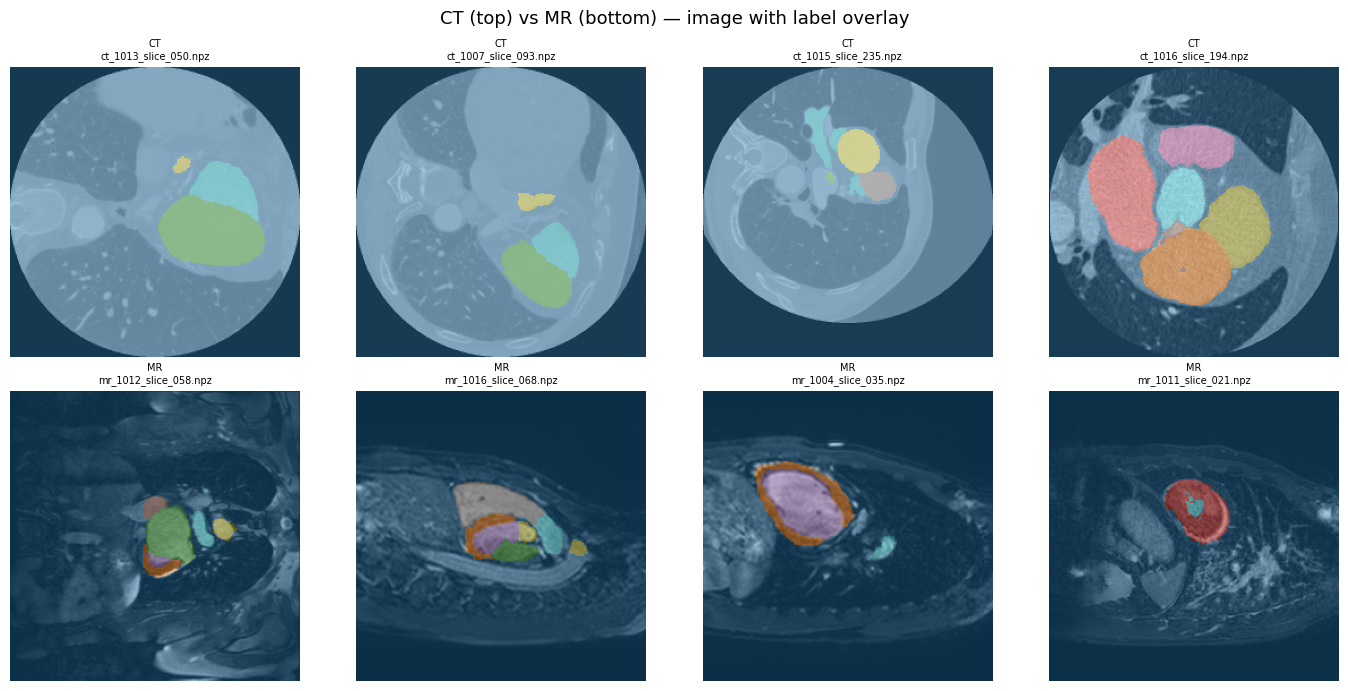

In [ ]:
N = 4
ct_files = random.sample(get_files('ct_256', 'train'), N)
mr_files = random.sample(get_files('mr_256', 'train'), N)

fig, axes = plt.subplots(2, N, figsize=(N * 3.5, 7))
fig.suptitle("CT (top) vs MR (bottom) - image with label overlay", fontsize=13)

for col, (ct_path, mr_path) in enumerate(zip(ct_files, mr_files)):
    for row, (path, title) in enumerate([(ct_path, 'CT'), (mr_path, 'MR')]):
        img, lbl = load_npz(path)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].imshow(lbl, cmap='tab10', alpha=0.4, interpolation='nearest')
        axes[row, col].set_title(f"{title}\n{os.path.basename(path)}", fontsize=7)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## Label class distribution
Count pixel frequencies for each label class across a random subset of files.

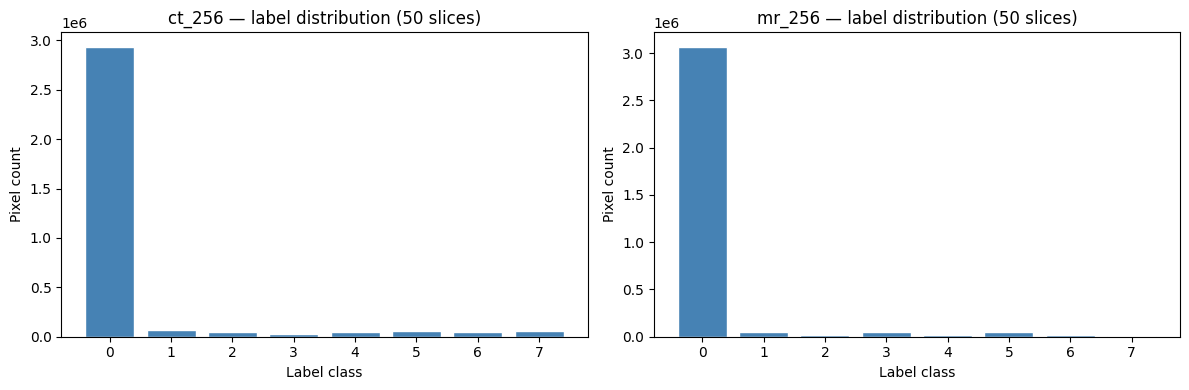

In [ ]:
N_SAMPLE_FILES = 50  

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, modality in zip(axes, ['ct_256', 'mr_256']):
    files = random.sample(get_files(modality, 'train'), N_SAMPLE_FILES)
    counts = {}
    for path in files:
        _, lbl = load_npz(path)
        for cls, cnt in zip(*np.unique(lbl, return_counts=True)):
            counts[int(cls)] = counts.get(int(cls), 0) + int(cnt)

    classes = sorted(counts.keys())
    ax.bar(classes, [counts[c] for c in classes], color='steelblue', edgecolor='white')
    ax.set_xlabel('Label class')
    ax.set_ylabel('Pixel count')
    ax.set_title(f"{modality} - label distribution ({N_SAMPLE_FILES} slices)")
    ax.set_xticks(classes)

plt.tight_layout()
plt.show()

## Browse a consecutive sequence of slices

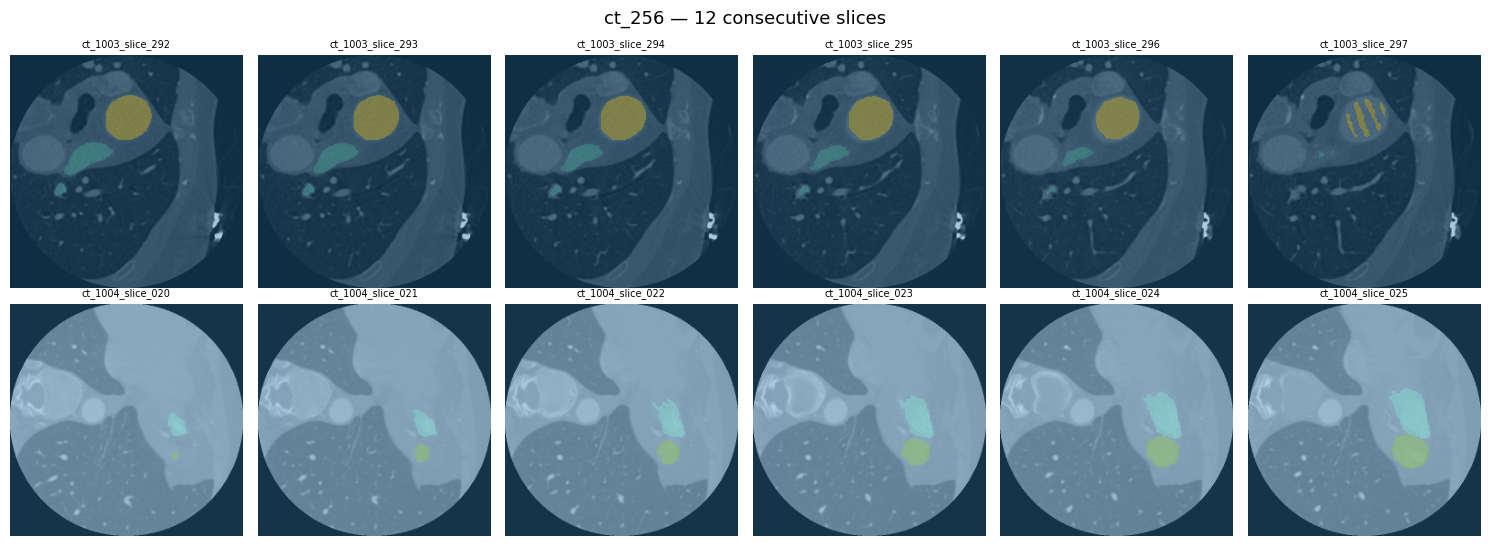

In [ ]:
MODALITY = 'ct_256'
SPLIT    = 'train'
N_SLICES = 12   

files = get_files(MODALITY, SPLIT)
start = random.randint(0, len(files) - N_SLICES)
seq   = files[start:start + N_SLICES]

cols = 6
rows = (N_SLICES + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.8))
axes = axes.flatten()

for i, path in enumerate(seq):
    img, lbl = load_npz(path)
    axes[i].imshow(img, cmap='gray')
    axes[i].imshow(lbl, cmap='tab10', alpha=0.35, interpolation='nearest')
    axes[i].set_title(os.path.basename(path).replace('.npz',''), fontsize=7)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f"{MODALITY} - {N_SLICES} consecutive slices", fontsize=13)
plt.tight_layout()
plt.show()